In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
data = np.load("../experiments/case1_data_qt.npz", allow_pickle=True)

In [3]:
# Display the keys in the data
print(data.files)

# Show a few lines of data for one of the keys, e.g., 'X'
print(data['X'][:5], data['loss'][:5])  # Adjust the key and slicing as needed

['X', 'loss', 'var_obj', 'worst_dmerc', 'iteration', 'seed', 'run_name', 'param_names']
[[0.30956055 0.712122   0.27722881 0.1111403  0.46180858 0.34934604
  0.65286954 0.48079233 0.49627639 0.69287454 0.53322588 0.82349974
  0.71168704 0.57466165 0.47583255 0.39630457 0.31476671 0.60575499
  0.43276344 0.50989325 0.49867448 0.31043241 0.49415595]
 [0.20983238 0.63576448 0.17750599 0.12289562 0.44756476 0.30248072
  0.76930244 0.47264826 0.62142192 0.77280069 0.50955675 0.849128
  0.75574556 0.60036905 0.37066913 0.35032777 0.40431047 0.59441108
  0.5653641  0.63542305 0.52716892 0.22743434 0.38881993]
 [0.31594418 0.83550481 0.26526904 0.1        0.61829568 0.3797609
  0.60867521 0.52974485 0.41585757 0.69404318 0.57822901 0.88036396
  0.7919289  0.56699542 0.55531287 0.29117292 0.22844933 0.62129148
  0.38529935 0.52970222 0.54324138 0.31745869 0.50854466]
 [0.3865502  0.66423618 0.3052803  0.1        0.35373804 0.30932442
  0.61715337 0.54060758 0.52715716 0.66842711 0.47621464 0.76

Min loss: 1.0055835910486195, Max loss: 4.803182814873137
Number of rows in loss_data: 1082


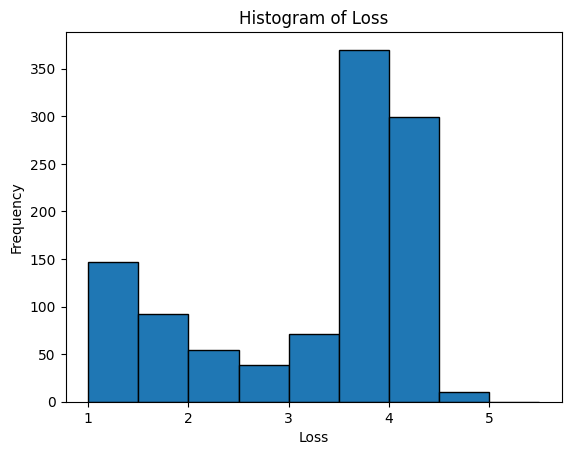

In [4]:
# Extract the 'loss' data
loss_data = data['loss']

# Define the bins starting from 5.5 with an interval of 0.5
bins = np.arange(1.0, 5.6, 0.5)

# Print min/max values of loss_data for debugging
print(f"Min loss: {np.min(loss_data)}, Max loss: {np.max(loss_data)}")
# Print number of rows in loss_data for debugging
print(f"Number of rows in loss_data: {loss_data.shape[0]}")

# Plot the histogram
plt.hist(loss_data, bins=bins, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of Loss')
plt.show()

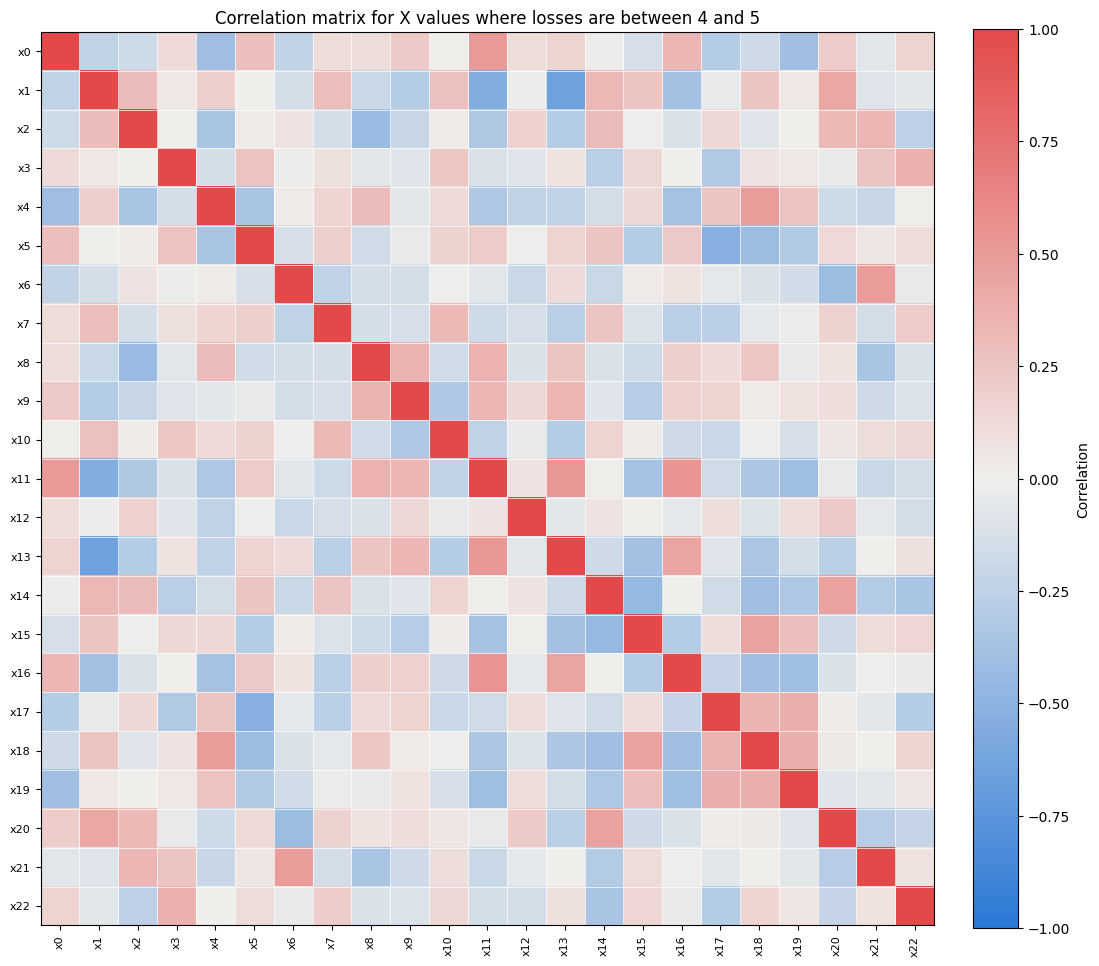

In [5]:
# Filter the data where losses are between 4 and 5
filtered_indices = (data['loss'] >= 4) & (data['loss'] <= 5)
filtered_X = data['X'][filtered_indices]

# Calculate the correlation matrix
correlation_matrix = np.corrcoef(filtered_X, rowvar=False)

# Parameter names, in the same column order as data['X'] (stored lexicographically,
# e.g. x0, x1, x10, x11, ...) — reorder numerically as x0, x1, x2, ...
param_names = list(data['param_names'])
order = sorted(range(len(param_names)), key=lambda i: int(param_names[i][1:]))
param_names = [param_names[i] for i in order]
correlation_matrix = correlation_matrix[np.ix_(order, order)]

# Diverging colormap: blue (negative) -> gray (zero) -> red (positive)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "corr_diverging", ["#2a78d6", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(correlation_matrix, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(param_names)))
ax.set_yticks(range(len(param_names)))
ax.set_xticklabels(param_names, rotation=90, fontsize=8)
ax.set_yticklabels(param_names, fontsize=8)

# Light gridlines to separate cells
ax.set_xticks(np.arange(-0.5, len(param_names), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(param_names), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

ax.set_title("Correlation matrix for X values where losses are between 4 and 5")
plt.tight_layout()
plt.show()

## PCA analysis (X values where loss is between 4 and 5)

In [6]:
from sklearn.decomposition import PCA

# filtered_indices = (data['loss'] >= 4) & (data['loss'] <= 5)
filtered_X = data['X'] # [filtered_indices]
filtered_loss = data['loss'] # [filtered_indices]

pca = PCA()
pca_scores = pca.fit_transform(data['X'])

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_for_90 = np.searchsorted(cumulative_var, 0.90) + 1

print(f"Explained variance ratio per component:\n{np.round(explained_var, 3)}")
print(f"\nCumulative explained variance:\n{np.round(cumulative_var, 3)}")
print(f"\nComponents needed to reach 90% variance: {n_for_90}")

Explained variance ratio per component:
[0.228 0.186 0.12  0.107 0.083 0.06  0.04  0.035 0.022 0.016 0.015 0.014
 0.011 0.01  0.009 0.008 0.008 0.007 0.006 0.006 0.004 0.003 0.001]

Cumulative explained variance:
[0.228 0.414 0.534 0.641 0.725 0.784 0.825 0.86  0.882 0.898 0.913 0.927
 0.937 0.948 0.957 0.965 0.973 0.98  0.986 0.991 0.995 0.999 1.   ]

Components needed to reach 90% variance: 11


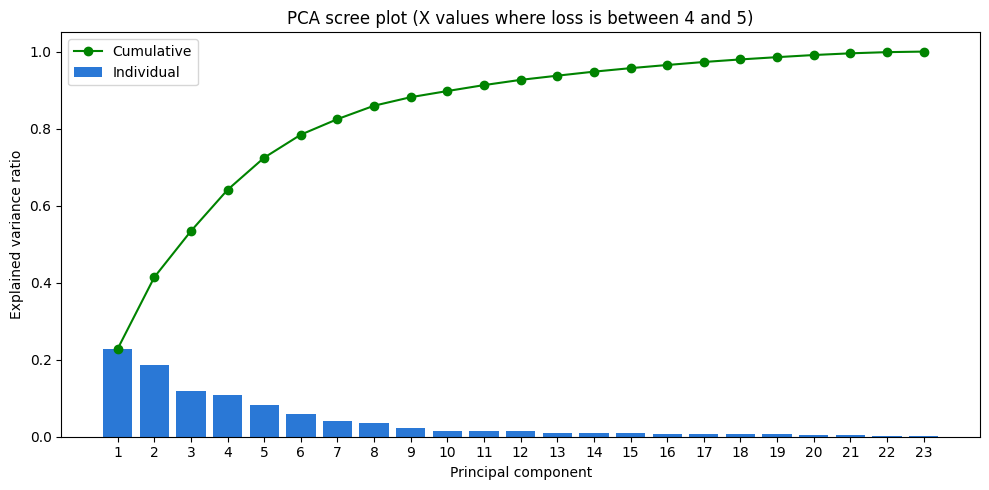

In [7]:
# Scree plot: individual and cumulative explained variance (same units, single axis)
fig, ax = plt.subplots(figsize=(10, 5))

components = np.arange(1, len(explained_var) + 1)
ax.bar(components, explained_var, color="#2a78d6", label="Individual")
ax.plot(components, cumulative_var, color="#008300", marker="o", label="Cumulative")

ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_xticks(components)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("PCA scree plot (X values where loss is between 4 and 5)")
plt.tight_layout()
plt.show()

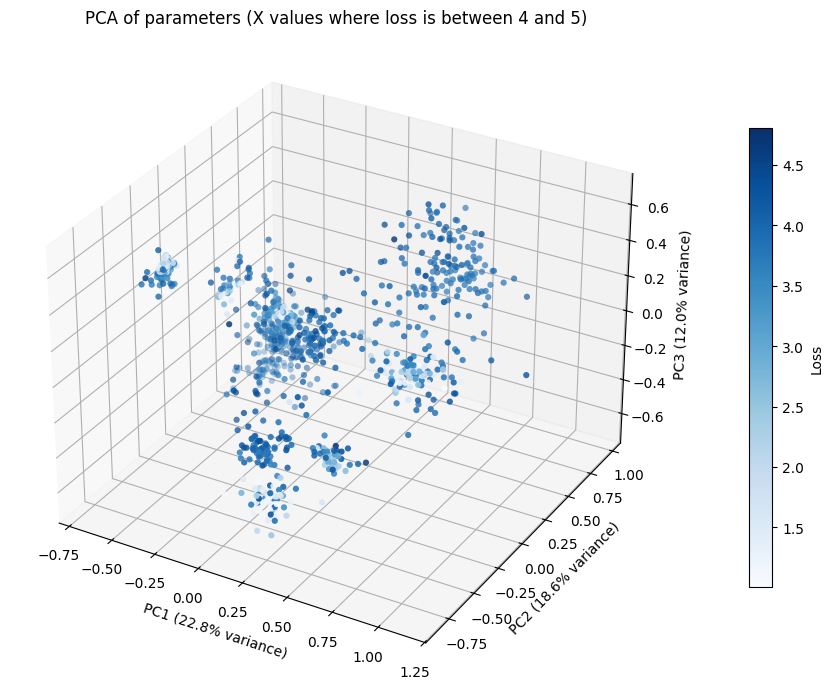

In [8]:
# PC1 vs PC2 vs PC3, colored by loss (sequential: low = light, high = dark)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")
sc = ax.scatter(
    pca_scores[:, 0], pca_scores[:, 1], pca_scores[:, 2],
    c=filtered_loss, cmap="Blues", s=20, edgecolor="none",
)
ax.set_xlabel(f"PC1 ({explained_var[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var[1] * 100:.1f}% variance)")
ax.set_zlabel(f"PC3 ({explained_var[2] * 100:.1f}% variance)")
ax.set_title("PCA of parameters (X values where loss is between 4 and 5)")

cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Loss")
plt.tight_layout()
plt.show()

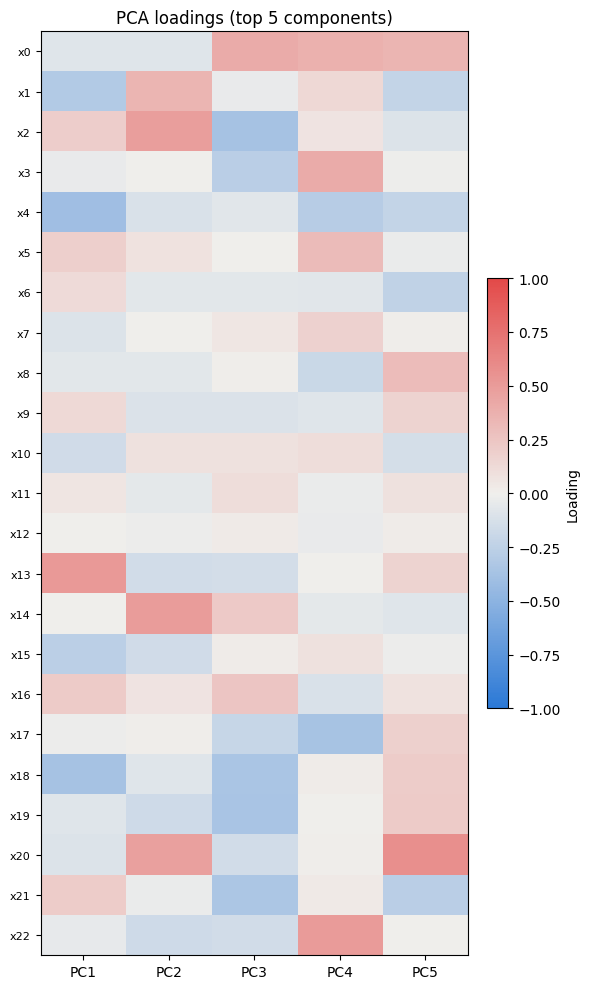

In [9]:
# Loadings for the top components, reordered to match the numeric x0..x22 labeling
n_components_show = 5
loadings = pca.components_[:n_components_show, order].T  # (n_features, n_components_show)

fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(loadings, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

ax.set_yticks(range(len(param_names)))
ax.set_yticklabels(param_names, fontsize=8)
ax.set_xticks(range(n_components_show))
ax.set_xticklabels([f"PC{i + 1}" for i in range(n_components_show)])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Loading")
ax.set_title("PCA loadings (top 5 components)")
plt.tight_layout()
plt.show()

## Supervised low-rank kernel ("active subspace") analysis

We fit a Gaussian process on the loss with kernel `k(x,y) = sigma_f^2 * phi(||W(x-y)||^2)`,
`phi` a squared exponential, and `W` an `r x d` matrix that plays the role of `U^T D` from the
original formulation. Rather than learning the combined map `W` from a single random
initialization (which turned out to be numerically fragile for small `r` -- the low-rank
projection can start out near-degenerate, giving a near-singular training covariance matrix),
we fit it in two stages:

1. **Fit `D`**: an ordinary full-rank ARD RBF GP on the same data gives one lengthscale per
   input dimension. Its inverse lengthscales are `D` -- a sensible per-feature scale learned
   directly from the data (rather than assumed via standardization).
2. **Fit `U`**: with `D` held fixed, fit a second GP whose kernel first rescales inputs by `D`
   and *then* projects through a learned `r x d` matrix (`raw_W`, playing the role of `U`).
   Because the inputs are already on a sensible per-feature scale after step 1, `raw_W` starts
   from a well-conditioned kernel instead of a near-constant one.

After fitting, we recover an orthonormal `U` and per-direction scales via an SVD of the
combined map `raw_W @ diag(1/D)`.

Rank `r` is chosen by held-out predictive performance (NLPD / RMSE) rather than fixed in
advance, so we sweep `r = 1..5` on a train/test split. GP training is done on a subsample
since exact GP inference is O(N^3).

In [10]:
import torch

torch.manual_seed(0)
rng = np.random.default_rng(0)

# Subsample for GP tractability (exact GP inference is O(N^3) in the training set size)
n_train, n_test = 1000, 30
perm = rng.permutation(filtered_X.shape[0])
train_idx, test_idx = perm[:n_train], perm[n_train:n_train + n_test]

X_train_raw, X_test_raw = filtered_X[train_idx], filtered_X[test_idx]
y_train_np, y_test_np = filtered_loss[train_idx], filtered_loss[test_idx]

# X is already the surface's dof vector, which lives in [0, 1]^d for every feature, so no
# per-feature standardization is needed here (unlike arbitrary-scale problems).
X_train_t = torch.tensor(X_train_raw, dtype=torch.float64)
X_test_t = torch.tensor(X_test_raw, dtype=torch.float64)
# Raw (uncentered) loss values -- BoTorch's Standardize outcome_transform below handles
# centering/scaling internally, and un-does it automatically on posterior predictions.
y_train_t = torch.tensor(y_train_np, dtype=torch.float64)
y_test_t = torch.tensor(y_test_np, dtype=torch.float64)

d = X_train_t.shape[1]
print(f"Train points: {n_train}, test points: {n_test}, input dim: {d}")

Train points: 1000, test points: 30, input dim: 23


In [11]:
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.models.utils.gpytorch_modules import get_covar_module_with_dim_scaled_prior
from gpytorch.kernels import Kernel, RBFKernel, ScaleKernel
from gpytorch.mlls import ExactMarginalLogLikelihood


def fit_ard_gp(seed=0):
    """Stage 1: fit an ordinary full-rank ARD RBF GP to get per-dimension lengthscales (D)."""
    torch.manual_seed(seed)
    model = SingleTaskGP(
        X_train_t, y_train_t.unsqueeze(-1),
        covar_module=get_covar_module_with_dim_scaled_prior(ard_num_dims=d, use_rbf_kernel=True),
        outcome_transform=Standardize(m=1),
    )
    fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
    return model


ard_model = fit_ard_gp()
D_lengthscales = ard_model.covar_module.lengthscale.detach().squeeze(0)  # shape (d,)
print("ARD lengthscales (D):", D_lengthscales.numpy())


class ActiveSubspaceKernel(Kernel):
    """RBF kernel evaluated after rescaling inputs by a fixed ARD diagonal D (from the
    separately-fit ARD GP above) and then projecting through a learned r x d matrix raw_W.

    Overall this is k(x, y) = sigma_f^2 * phi(||W_full(x - y)||^2) with W_full = raw_W @ diag(1/D)
    -- ScaleKernel (wrapped around this below) supplies sigma_f^2, and gpytorch's own RBFKernel
    supplies phi. The base RBFKernel's own lengthscale is fixed to 1 since W_full already
    absorbs both D's per-feature scaling and raw_W's rank-r projection.
    """

    has_lengthscale = False

    def __init__(self, d, r, D_lengthscales, **kwargs):
        super().__init__(**kwargs)
        self.register_buffer("inv_D", 1.0 / D_lengthscales.to(torch.double))
        self.register_parameter("raw_W", torch.nn.Parameter(torch.randn(r, d, dtype=torch.double) / d ** 0.5))
        self.base_kernel = RBFKernel()
        self.base_kernel.lengthscale = 1.0
        self.base_kernel.raw_lengthscale.requires_grad_(False)

    def forward(self, x1, x2, diag=False, **params):
        z1 = (x1 * self.inv_D) @ self.raw_W.T
        z2 = (x2 * self.inv_D) @ self.raw_W.T
        return self.base_kernel.forward(z1, z2, diag=diag, **params)


def fit_gp(r, seed=0):
    """Stage 2: fit a SingleTaskGP with the active-subspace kernel above (D fixed from the ARD
    fit, raw_W learned), via BoTorch's own fit_gpytorch_mll (L-BFGS-B on the marginal log
    likelihood) instead of a hand-rolled Adam loop with a manually-derived Cholesky-based NLL."""
    torch.manual_seed(seed)
    model = SingleTaskGP(
        X_train_t, y_train_t.unsqueeze(-1),
        covar_module=ScaleKernel(ActiveSubspaceKernel(d=d, r=r, D_lengthscales=D_lengthscales)),
        outcome_transform=Standardize(m=1),
    )
    fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
    return model

ARD lengthscales (D): [2.70573062 0.84937666 0.30421307 0.04092504 0.26364726 4.29591701
 0.64071696 0.28871567 3.16650217 0.41866406 2.25315382 5.72080024
 4.35868547 4.23152206 1.29194913 2.18784551 4.72808149 4.21572675
 2.27582843 0.37331315 0.08415302 0.74455064 4.25828962]


In [12]:
results = []
fitted = {}
for r in [1, 2, 3, 4, 5]:
    model = fit_gp(r)
    fitted[r] = model

    with torch.no_grad():
        posterior = model.posterior(X_test_t)
        mean = posterior.mean.squeeze(-1)
        var = posterior.variance.squeeze(-1)

    resid = y_test_t - mean
    rmse = torch.sqrt((resid ** 2).mean()).item()
    nlpd = (0.5 * torch.log(2 * np.pi * var) + resid ** 2 / (2 * var)).mean().item()
    results.append({"r": r, "rmse": rmse, "nlpd": nlpd})

    print(f"r={r}: held-out RMSE={rmse:.4f}, NLPD={nlpd:.4f}")

r=1: held-out RMSE=0.9060, NLPD=74.0467
r=2: held-out RMSE=0.4126, NLPD=8.0552
r=3: held-out RMSE=0.4424, NLPD=9.6421


KeyboardInterrupt: 

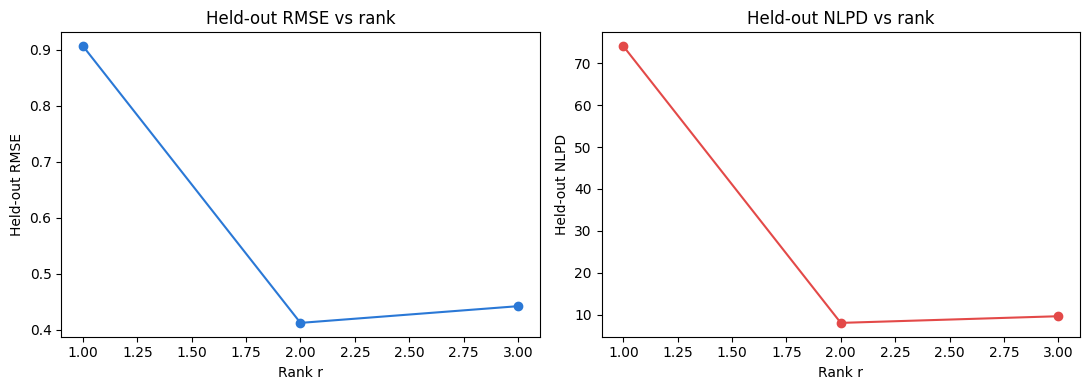

Best rank by held-out NLPD: r=2


In [13]:
rs = [res["r"] for res in results]
rmses = [res["rmse"] for res in results]
nlpds = [res["nlpd"] for res in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rs, rmses, color="#2a78d6", marker="o")
axes[0].set_xlabel("Rank r")
axes[0].set_ylabel("Held-out RMSE")
axes[0].set_title("Held-out RMSE vs rank")

axes[1].plot(rs, nlpds, color="#e34948", marker="o")
axes[1].set_xlabel("Rank r")
axes[1].set_ylabel("Held-out NLPD")
axes[1].set_title("Held-out NLPD vs rank")

plt.tight_layout()
plt.show()

best_r = min(results, key=lambda res: res["nlpd"])["r"]
print(f"Best rank by held-out NLPD: r={best_r}")

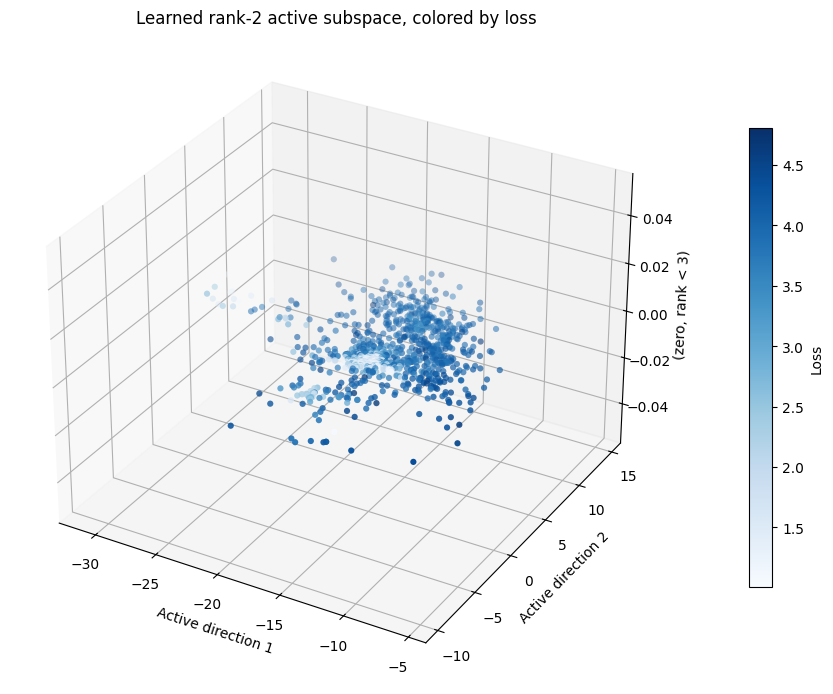

In [14]:
# Recover an orthonormal subspace U and per-direction scales (like a diagonal D) via
# an SVD of the fitted combined map W = raw_W @ diag(1/D)
best_kernel = fitted[best_r].covar_module.base_kernel
W_best = (best_kernel.raw_W * best_kernel.inv_D).detach()
_, S_svd, Vt_svd = torch.linalg.svd(W_best, full_matrices=False)
U_orthonormal = Vt_svd.T.numpy()  # (d, best_r), orthonormal directions in x-space

Z_all = (filtered_X @ U_orthonormal) * S_svd.numpy()  # projected coords, matches W @ x

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")
y_axis = Z_all[:, 1] if best_r > 1 else np.zeros_like(Z_all[:, 0])
z_axis = Z_all[:, 2] if best_r > 2 else np.zeros_like(Z_all[:, 0])
sc = ax.scatter(Z_all[:, 0], y_axis, z_axis, c=filtered_loss, cmap="Blues", s=20, edgecolor="none")
ax.set_xlabel("Active direction 1")
ax.set_ylabel("Active direction 2" if best_r > 1 else "(zero, rank < 2)")
ax.set_zlabel("Active direction 3" if best_r > 2 else "(zero, rank < 3)")
ax.set_title(f"Learned rank-{best_r} active subspace, colored by loss")
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Loss")
plt.tight_layout()
plt.show()

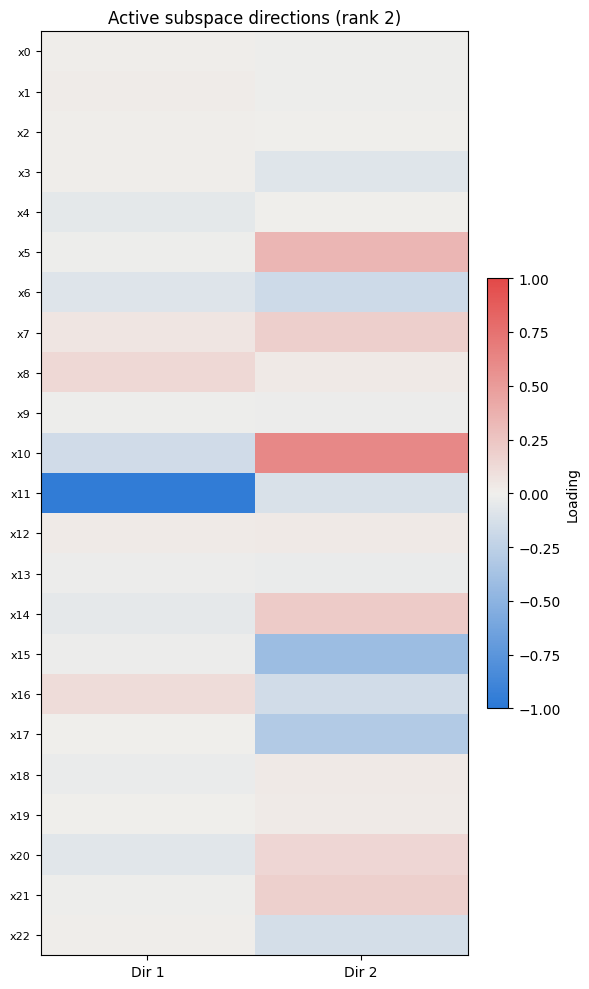

In [15]:
# Loadings of the learned active-subspace directions, reordered to match x0..x22
loadings_active = U_orthonormal[order]

fig, ax = plt.subplots(figsize=(4 + best_r, 10))
im = ax.imshow(loadings_active, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

ax.set_yticks(range(len(param_names)))
ax.set_yticklabels(param_names, fontsize=8)
ax.set_xticks(range(best_r))
ax.set_xticklabels([f"Dir {i + 1}" for i in range(best_r)])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Loading")
ax.set_title(f"Active subspace directions (rank {best_r})")
plt.tight_layout()
plt.show()